In [ ]:
from ISLP import load_data
import numpy as np
import pandas as pd
from ISLP.models import (ModelSpec,
                         poly, 
                         bs,
                         sklearn_sm)
from sklearn.model_selection import (cross_validate,
                                     KFold,
                                     train_test_split)
from statsmodels.api import OLS
from matplotlib.pyplot import subplots
from statsmodels.stats.anova import anova_lm

# 9. # 
This question uses the variables dis (the weighted mean of distances
to five Boston employment centers) and nox (nitrogen oxides concentration in parts per 10 million) from the Boston data. We will treat
dis as the predictor and nox as the response.

(a) Use the poly() function from the ISLP.models module to fit a
cubic polynomial regression to predict nox using dis. Report the
regression output, and plot the resulting data and polynomial
fits.

(b) Plot the polynomial fits for a range of different polynomial
degrees (say, from 1 to 10), and report the associated residual
sum of squares.

(c) Perform cross-validation or another approach to select the optimal degree for the polynomial, and explain your results.

(d) Use the bs() function from the ISLP.models module to fit a re
gression spline to predict nox using dis. Report the output for
the fit using four degrees of freedom. How did you choose the
knots? Plot the resulting fit.

(e) Now fit a regression spline for a range of degrees of freedom, and
plot the resulting fits and report the resulting RSS. Describe the
results obtained.

(f) Perform cross-validation or another approach in order to select
the best degrees of freedom for a regression spline on this data.
Describe your results.

In [2]:
Boston = load_data('Boston')
Boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  lstat    506 non-null    float64
 12  medv     506 non-null    float64
dtypes: float64(10), int64(3)
memory usage: 51.5 KB


In [3]:
Boston[['nox', 'dis']].corr()

,nox,dis
nox,1.00000,-0.76923
dis,-0.76923,1.00000


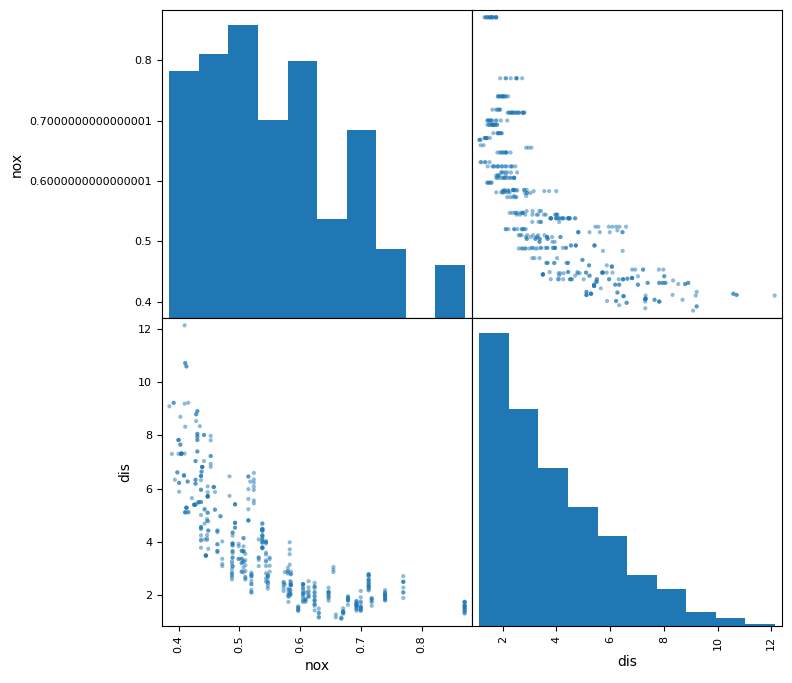

In [4]:
pd.plotting.scatter_matrix(Boston[['nox', 'dis']],figsize=(8,8));

In [5]:
X = Boston.drop(columns=['nox'])
y = Boston['nox']
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, train_size=0.2)

(a) Use the poly() function from the ISLP.models module to fit a
cubic polynomial regression to predict nox using dis. Report the
regression output, and plot the resulting data and polynomial
fits.

In [6]:
transformador_poly_cubico = ModelSpec([poly('dis',3)]).fit(X_treino)
modelo_poly_cubico = OLS(y_treino, transformador_poly_cubico.transform(X_treino)).fit()
modelo_poly_cubico.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    nox   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.716
Method:                 Least Squares   F-statistic:                     85.06
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           4.69e-27
Time:                        11:18:44   Log-Likelihood:                 145.80
No. Observations:                 101   AIC:                            -283.6
Df Residuals:                      97   BIC:                            -273.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
intercept                  0.5485      0.006     94.561      0.000       0.537       0.560
poly(dis, degree=3)[0]    -0.8349      0.058    -14.323      0.000      -0.951      -0.719
poly(dis, degree=3)[1]     0.3821      0.058      6.554      0.000       0.266       0.498
poly(dis, degree=3)[2]    -0.1549      0.058     -2.658      0.009      -0.271      -0.039
==============================================================================
Omnibus:                       25.648   Durbin-Watson:                   2.080
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               39.346
Skew:                           1.143   Prob(JB):                     2.86e-09
Kurtosis:                       5.030   Cond. No.                         10.0
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

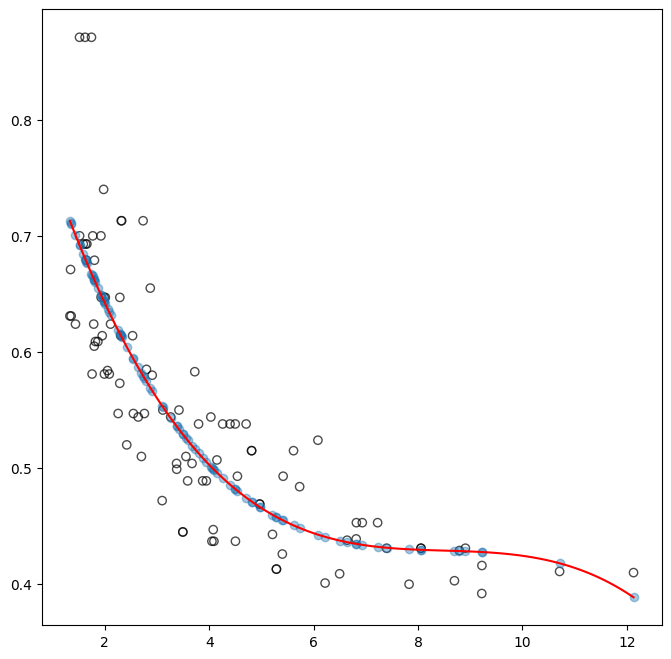

In [7]:
modelo_poly_cubico_predicao_treino = modelo_poly_cubico.predict(transformador_poly_cubico.transform(X_treino))
modelo_poly_cubico_predicao_teste = modelo_poly_cubico.predict(transformador_poly_cubico.transform(X_teste))
dis_seq = np.linspace(X_treino['dis'].min(), X_treino['dis'].max(), 100)
dis_seq_df = pd.DataFrame({'dis':dis_seq})

ax = subplots(figsize=(8,8))[1]
ax.scatter(X_treino['dis'], y_treino, facecolor='none', edgecolors='black', alpha=0.7)
ax.scatter(X_treino['dis'], modelo_poly_cubico_predicao_treino, alpha=0.4)
ax.plot(dis_seq_df.values, modelo_poly_cubico.predict(transformador_poly_cubico.transform(dis_seq_df)), color='r');

(b) Plot the polynomial fits for a range of different polynomial
degrees (say, from 1 to 10), and report the associated residual
sum of squares.

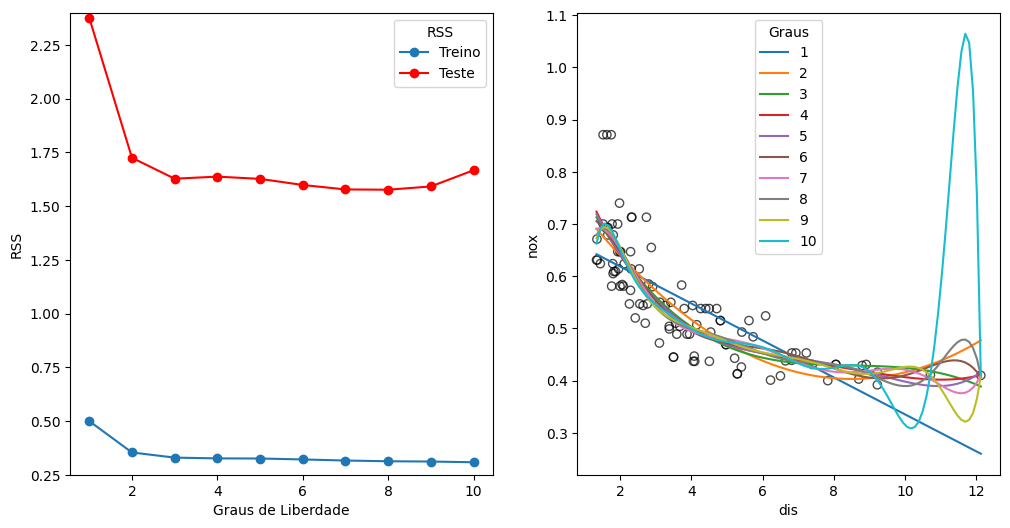

In [75]:
graus_polinomios = range(1, 11)
ax = subplots(1,2,figsize=(12,6))[1]

transformadores_poly = [ModelSpec([poly('dis', degree=grau)]).fit(X_treino) for grau in graus_polinomios]
X_treinos_poly = [transformador.transform(X_treino) for transformador in transformadores_poly]
modelos_poly = [OLS(y_treino, _X_treino).fit() for _X_treino in X_treinos_poly]

y_predicoes_treino_poly = [modelo.predict(transformador.transform(X_treino)) for modelo, transformador in zip(modelos_poly, transformadores_poly)] 
rss_treinos_poly = [np.sum((_y_predicao - y)**2) for _y_predicao in y_predicoes_treino_poly]

y_predicoes_teste_poly = [modelo.predict(transformador.transform(X_teste)) for modelo, transformador in zip (modelos_poly, transformadores_poly)]
rss_teste_poly = [np.sum((_y_predicao - y_teste)**2) for _y_predicao in y_predicoes_teste_poly]

ax[0].plot(graus_polinomios, rss_treinos_poly, '-o', label='Treino')
ax[0].plot(graus_polinomios, rss_teste_poly, 'r-o', label='Teste')
ax[0].set_ylim((0.25, 2.4))
ax[0].set_xlabel('Graus de Liberdade')
ax[0].set_ylabel('RSS')

ax[1].scatter(X_treino['dis'], y_treino, facecolor='none', edgecolors='black', alpha=0.7)
ax[1].set_xlabel('dis')
ax[1].set_ylabel('nox')
for modelo, transformador, grau in zip(modelos_poly, transformadores_poly, graus_polinomios):
    ax[1].plot(dis_seq, modelo.predict(transformador.transform(dis_seq_df)), label=grau)
ax[0].legend(title='RSS')
ax[1].legend(title='Graus');


(c) Perform cross-validation or another approach to select the optimal degree for the polynomial, and explain your results.

In [76]:
anova_lm(*modelos_poly)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,99.0,0.499577,0.0,NaN,NaN,NaN
1,98.0,0.353606,1.0,0.145971,42.653444,2.921160e-09
2,97.0,0.329607,1.0,0.023999,7.012512,9.448549e-03
3,96.0,0.326039,1.0,0.003568,1.042648,3.097728e-01
4,95.0,0.325487,1.0,0.000552,0.161274,6.888881e-01
5,94.0,0.321051,1.0,0.004436,1.296260,2.577909e-01
6,93.0,0.316096,1.0,0.004955,1.447949,2.319116e-01
7,92.0,0.312645,1.0,0.003451,1.008254,3.179552e-01
8,91.0,0.311394,1.0,0.001251,0.365620,5.469064e-01
9,90.0,0.308004,1.0,0.003390,0.990620,3.222594e-01


In [101]:
cv_scores = [np.mean(
                    cross_validate(sklearn_sm(OLS, ModelSpec([poly('dis',grau)])),
                                   X_treino,
                                   y_treino,
                                   cv=5)['test_score']
                    )
                    for grau in graus_polinomios
            ]
df_cv_scores = pd.DataFrame(cv_scores,
                            index=graus_polinomios,
                            columns=['cv_score'])
df_cv_scores

,cv_score
1,0.005069
2,0.003762
3,0.003611
4,0.003565
5,0.003835
6,0.007590
7,0.020617
8,0.041135
9,0.069095
10,3.817293


(d) Use the bs() function from the ISLP.models module to fit a re
gression spline to predict nox using dis. Report the output for
the fit using four degrees of freedom. How did you choose the
knots? Plot the resulting fit.

count    101.000000
mean       3.976053
std        2.358603
min        1.332500
25%        2.010700
50%        3.421100
75%        5.211900
max       12.126500
Name: dis, dtype: float64


<Axes: ylabel='Density'>

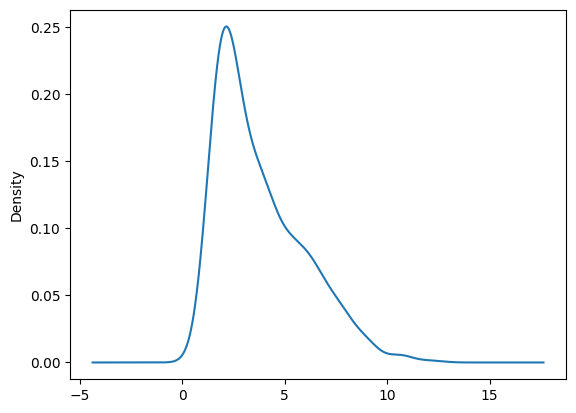

In [154]:
print(X_treino['dis'].describe())
Boston.dis.plot.density()


In [153]:
OLS(y_treino, ModelSpec([bs('dis', internal_knots=np.percentile(X_treino.dis, [.4]))]).fit_transform(X_treino)).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    nox   R-squared:                       0.731
Model:                            OLS   Adj. R-squared:                  0.719
Method:                 Least Squares   F-statistic:                     65.06
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           1.67e-26
Time:                        20:12:44   Log-Likelihood:                 146.90
No. Observations:                 101   AIC:                            -283.8
Df Residuals:                      96   BIC:                            -270.7
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
========================================================================================================
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
intercept                                0.6310      0.058     10.887      0.000       0.516       0.746
bs(dis, internal_knots=[1.33746])[0]     0.0868      0.060      1.452      0.150      -0.032       0.205
bs(dis, internal_knots=[1.33746])[1]    -0.3474      0.073     -4.750      0.000      -0.493      -0.202
bs(dis, internal_knots=[1.33746])[2]    -0.1212      0.087     -1.389      0.168      -0.294       0.052
bs(dis, internal_knots=[1.33746])[3]    -0.2456      0.077     -3.177      0.002      -0.399      -0.092
==============================================================================
Omnibus:                       24.517   Durbin-Watson:                   2.012
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               36.508
Skew:                           1.112   Prob(JB):                     1.18e-08
Kurtosis:                       4.931   Cond. No.                         26.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [152]:
OLS(y_treino, ModelSpec([bs('dis', df=4)]).fit_transform(X_treino)).fit().summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    nox   R-squared:                       0.725
Model:                            OLS   Adj. R-squared:                  0.713
Method:                 Least Squares   F-statistic:                     63.23
Date:                Mon, 14 Sep 2026   Prob (F-statistic):           4.49e-26
Time:                        20:07:52   Log-Likelihood:                 145.85
No. Observations:                 101   AIC:                            -281.7
Df Residuals:                      96   BIC:                            -268.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
intercept            0.7184      0.022     31.945      0.000       0.674       0.763
bs(dis, df=4)[0]    -0.0925      0.038     -2.431      0.017      -0.168      -0.017
bs(dis, df=4)[1]    -0.3713      0.044     -8.375      0.000      -0.459      -0.283
bs(dis, df=4)[2]    -0.2524      0.069     -3.680      0.000      -0.389      -0.116
bs(dis, df=4)[3]    -0.3257      0.056     -5.800      0.000      -0.437      -0.214
==============================================================================
Omnibus:                       25.101   Durbin-Watson:                   2.082
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               38.023
Skew:                           1.127   Prob(JB):                     5.54e-09
Kurtosis:                       4.989   Cond. No.                         15.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""